Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2778.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2788.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2794.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2799.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2805.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2808.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2822.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2827.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2831.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemic

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.0329 - loss: -8.3168
Epoch 1: val_accuracy improved from -inf to 0.03082, saving model to best_vgg16_fruit.h5


786/786 ━━━━━━━━━━━━━━━━━━━━ 401s 490ms/step - accuracy: 0.0329 - loss: -8.3328 - val_accuracy: 0.0308 - val_loss: -55.2720 - learning_rate: 1.0000e-04
Epoch 2/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.0325 - loss: -74.2749
Epoch 2: val_accuracy improved from 0.03082 to 0.03101, saving model to best_vgg16_fruit.h5


786/786 ━━━━━━━━━━━━━━━━━━━━ 359s 456ms/step - accuracy: 0.0325 - loss: -74.3032 - val_accuracy: 0.0310 - val_loss: -163.1494 - learning_rate: 1.0000e-04
Epoch 3/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.0318 - loss: -190.1908
Epoch 3: val_accuracy improved from 0.03101 to 0.03175, saving model to best_vgg16_fruit.h5


786/786 ━━━━━━━━━━━━━━━━━━━━ 361s 460ms/step - accuracy: 0.0318 - loss: -190.2263 - val_accuracy: 0.0317 - val_loss: -319.7355 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 3.
169/169 ━━━━━━━━━━━━━━━━━━━━ 37s 218ms/step - accuracy: 0.0229 - loss: 955.7664
✅ Độ chính xác trên test set: 0.0314
✅ Đã lưu model: vgg16_fruit_model.keras


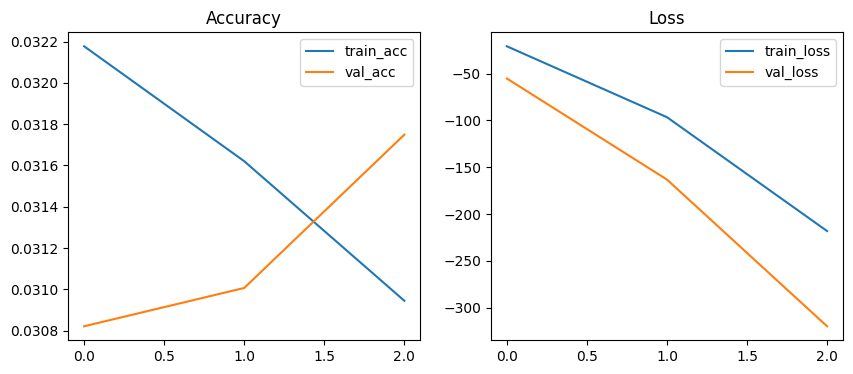

In [ ]:
# ==========================================================
# Mô hình: VGG16 – Nhận diện Trái cây tươi vs Trái cây hư / hóa chất
# Dành cho Google Colab – Train nhanh 3 epoch
# ==========================================================

# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---- CHỈNH ĐƯỜNG DẪN NÀY NẾU KHÁC ----
rar_path = "/content/drive/MyDrive/split_dataset.rar"   # file .rar chứa train/val/test
extract_to = "/content/dataset"

# 2) Cài unrar và giải nén
!apt-get update -qq
!apt-get install -y -qq unrar
import os
if not os.path.exists(rar_path):
    raise FileNotFoundError(f"Không tìm thấy {rar_path}. Kiểm tra lại đường dẫn trong Drive.")
os.makedirs(extract_to, exist_ok=True)
print("🔄 Đang giải nén...")
!unrar x -y "{rar_path}" "{extract_to}/"
print("✅ Giải nén hoàn tất.")

# 3) Kiểm tra cấu trúc thư mục
!find "{extract_to}" -maxdepth 3 -type d | sed -n '1,200p'

# 4) Import thư viện
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

# 5) Dò đường dẫn train / val / test
train_dir = os.path.join(extract_to, "train")
val_dir   = os.path.join(extract_to, "val")
test_dir  = os.path.join(extract_to, "test")

if not (os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir)):
    for root, dirs, files in os.walk(extract_to):
        if set(["train","val","test"]).issubset(set(dirs)):
            base = root
            train_dir = os.path.join(base, "train")
            val_dir   = os.path.join(base, "val")
            test_dir  = os.path.join(base, "test")
            break

print("✅ Train:", train_dir)
print("✅ Val:  ", val_dir)
print("✅ Test: ", test_dir)

# 6) Data generators
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print("📂 Class indices:", train_gen.class_indices)

# 7) Tạo mô hình VGG16
base_model = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze toàn bộ VGG16

# Tạo head phân loại riêng
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 8) Callbacks
checkpoint = ModelCheckpoint("best_vgg16_fruit.h5", monitor="val_accuracy", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

# 9) Train nhanh 3 epoch
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=3,
    callbacks=[checkpoint, reduce_lr, early_stop],
    verbose=1
)

# 10) Đánh giá trên test set
model.load_weights("best_vgg16_fruit.h5")
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"✅ Độ chính xác trên test set: {test_acc:.4f}")

# 11) Lưu model
model.save("vgg16_fruit_model.keras")
print("✅ Đã lưu model: vgg16_fruit_model.keras")

# 12) Vẽ biểu đồ Accuracy / Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss"); plt.legend()
plt.show()


Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2720.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2734.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2735.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2736.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2739.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2740.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2741.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2751.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2753.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemic

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.3234 - loss: 4.1375
Epoch 1: val_accuracy improved from -inf to 0.49981, saving model to best_vgg16_fruit_multiclass.keras
785/785 ━━━━━━━━━━━━━━━━━━━━ 370s 468ms/step - accuracy: 0.3235 - loss: 4.1366 - val_accuracy: 0.4998 - val_loss: 1.7092 - learning_rate: 1.0000e-05
Epoch 2/3
  1/785 ━━━━━━━━━━━━━━━━━━━━ 2:16 174ms/step - accuracy: 0.4688 - loss: 2.8302

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.49981 to 0.50037, saving model to best_vgg16_fruit_multiclass.keras
785/785 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.4688 - loss: 2.8302 - val_accuracy: 0.5004 - val_loss: 1.7076 - learning_rate: 1.0000e-05
Epoch 3/3
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5002 - loss: 2.1955
Epoch 3: val_accuracy improved from 0.50037 to 0.62928, saving model to best_vgg16_fruit_multiclass.keras
785/785 ━━━━━━━━━━━━━━━━━━━━ 369s 470ms/step - accuracy: 0.5002 - loss: 2.1952 - val_accuracy: 0.6293 - val_loss: 1.2331 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 3.
169/169 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step
Confusion matrix:
 [[1547  336  646]
 [   3  157    7]
 [ 639  416 1639]]

Classification report:
               precision    recall  f1-score   support

Fake_Chemical     0.7067    0.6117    0.6558      2529
  Fake_Origin     0.1727    0.9401    0.2918       167
         Real     0.7151    0.6084   

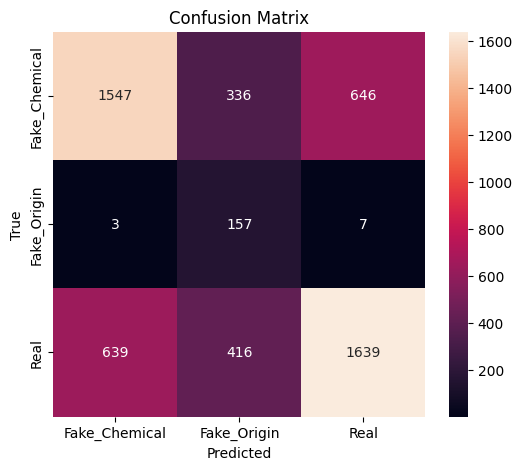

✅ Đã lưu model: vgg16_fruit_model_multiclass.keras


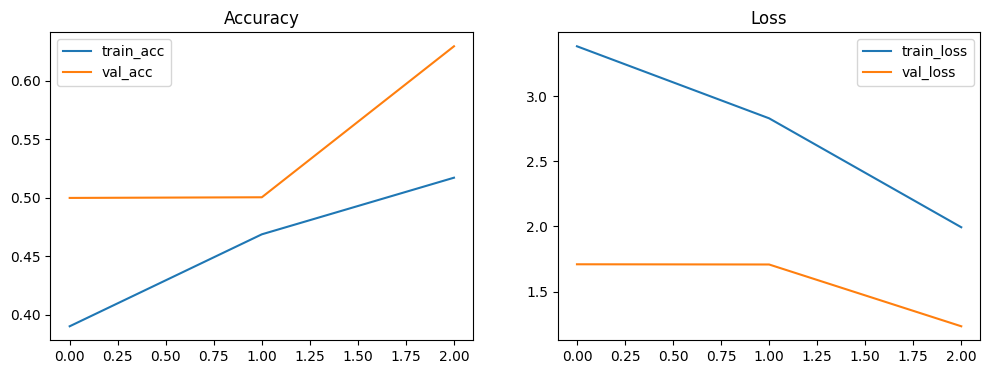

In [ ]:
# Colab-ready: VGG16 - Nhận diện 3 lớp: Fake_Chemical / Fake_Origin / Real
# Chạy nhanh 3 epoch, xử lý multi-class + class_weight cho imbalance

# 1) Mount Google Drive (nếu chưa mount)
from google.colab import drive
drive.mount('/content/drive')

# ---- CHỈNH ĐƯỜNG DẪN NẾU CẦN ----
rar_path = "/content/drive/MyDrive/split_dataset.rar"   # file .rar chứa train/val/test
extract_to = "/content/dataset"

# 2) (nếu cần) giải nén
!apt-get update -qq
!apt-get install -y -qq unrar
import os
if not os.path.exists(rar_path):
    raise FileNotFoundError(f"Không tìm thấy {rar_path}. Kiểm tra lại đường dẫn trong Drive.")
os.makedirs(extract_to, exist_ok=True)
print("🔄 Đang giải nén...")
!unrar x -y "{rar_path}" "{extract_to}/"
print("✅ Giải nén hoàn tất.")

# 3) Import thư viện
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

# những thư viện dùng để báo cáo
!pip install -q scikit-learn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# 4) Dò đường dẫn train / val / test
train_dir = os.path.join(extract_to, "train")
val_dir   = os.path.join(extract_to, "val")
test_dir  = os.path.join(extract_to, "test")

if not (os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir)):
    for root, dirs, files in os.walk(extract_to):
        if set(["train","val","test"]).issubset(set(dirs)):
            base = root
            train_dir = os.path.join(base, "train")
            val_dir   = os.path.join(base, "val")
            test_dir  = os.path.join(base, "test")
            break

print("✅ Train:", train_dir)
print("✅ Val:  ", val_dir)
print("✅ Test: ", test_dir)

# 5) Data generators (multi-class -> class_mode='categorical')
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("📂 Class indices:", train_gen.class_indices)

# 6) Kiểm tra phân bố nhãn
print("Phân bố nhãn train:", Counter(train_gen.classes))
print("Phân bố nhãn val:  ", Counter(val_gen.classes))
print("Phân bố nhãn test: ", Counter(test_gen.classes))

num_classes = len(train_gen.class_indices)
print("Số lớp phát hiện:", num_classes)

if num_classes < 2:
    raise ValueError("Số lớp phải >= 2.")

# 7) Tính class_weight để xử lý imbalance
classes = np.unique(train_gen.classes)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_gen.classes)
class_weight_dict = {int(c): float(w) for c,w in zip(classes, class_weights)}
print("Class weight:", class_weight_dict)

# 8) Tạo mô hình VGG16 (multi-class head)
base_model = VGG16(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)   # num_classes outputs
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 9) Callbacks
checkpoint = ModelCheckpoint("best_vgg16_fruit_multiclass.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-7, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# 10) Train nhanh 3 epoch (with class_weight)
steps_per_epoch = max(1, train_gen.samples // BATCH_SIZE)
validation_steps = max(1, val_gen.samples // BATCH_SIZE)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=3,
    callbacks=[checkpoint, reduce_lr, early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

# 11) Đánh giá & báo cáo chi tiết trên test set
model.load_weights("best_vgg16_fruit_multiclass.keras")

# Dự đoán (chú ý lấy đủ số mẫu: batches * batch_size có thể bỏ qua 1-2 sample cuối cùng)
test_steps = int(np.ceil(test_gen.samples / BATCH_SIZE))
preds_proba = model.predict(test_gen, steps=test_steps, verbose=1)
preds = np.argmax(preds_proba, axis=1)
y_true = test_gen.classes[:len(preds)]  # align length

# Confusion matrix và classification report
labels = list(train_gen.class_indices.keys())
cm = confusion_matrix(y_true, preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:")
print(classification_report(y_true, preds, target_names=labels, digits=4))

# Vẽ confusion matrix
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

# 12) Lưu model
model.save("vgg16_fruit_model_multiclass.keras")
print("✅ Đã lưu model: vgg16_fruit_model_multiclass.keras")

# 13) Vẽ biểu đồ Accuracy / Loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train_acc')
plt.plot(history.history.get('val_accuracy', []), label='val_acc')
plt.title("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.title("Loss"); plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

overall_acc = accuracy_score(y_true, preds)
print(f"🔹 Độ chính xác chung (Overall Accuracy): {overall_acc * 100:.2f}%")

🔹 Độ chính xác chung (Overall Accuracy): 62.02%
